Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* No ResNet
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 80 blocks (MaxPool2D in each second block)

In [7]:
out_channels = 8
size = 64

model_blocks = [
    nn.Conv2d(3, out_channels, 3, 1, 1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU()
]

for stage in range(5):

    for i in range(20):

        conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        bn = nn.BatchNorm2d(out_channels)

        model_blocks.extend([conv, bn, nn.ReLU()])

    if stage < 3:
        model_blocks.append(nn.MaxPool2d(2, 2))
        size //= 2
    if stage<4:
        model_blocks.extend([
            nn.Conv2d(out_channels, out_channels*2, 3, 1, 1),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU()
    ])

        out_channels *= 2

print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final Out Channels = 128
Final Shape = 8


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(out_channels * size * size, out_channels),
    nn.ReLU(),
    nn.Linear(out_channels, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment6/",
    save_checkpoints=10,
    print_every=5
    )

In [11]:
history = trainer.fit(100)

Epoch [5/100] | Train Loss: 1.1014 | Val Loss: 1.1963 | Train Acc: 0.3332 | Val Acc: 0.3142 | Train F1: 0.2740 | Val F1: 0.2078
Epoch [10/100] | Train Loss: 1.0985 | Val Loss: 1.1007 | Train Acc: 0.3544 | Val Acc: 0.3562 | Train F1: 0.2622 | Val F1: 0.2070
Epoch [15/100] | Train Loss: 1.0969 | Val Loss: 1.1388 | Train Acc: 0.3587 | Val Acc: 0.3496 | Train F1: 0.2913 | Val F1: 0.2016
Epoch [20/100] | Train Loss: 1.0981 | Val Loss: 1.1147 | Train Acc: 0.3478 | Val Acc: 0.3739 | Train F1: 0.2799 | Val F1: 0.2522
Epoch [25/100] | Train Loss: 1.0926 | Val Loss: 1.1135 | Train Acc: 0.3379 | Val Acc: 0.3673 | Train F1: 0.2705 | Val F1: 0.2903
Epoch [30/100] | Train Loss: 1.0961 | Val Loss: 1.1188 | Train Acc: 0.3573 | Val Acc: 0.3606 | Train F1: 0.2878 | Val F1: 0.2251
Epoch [35/100] | Train Loss: 1.0940 | Val Loss: 1.2030 | Train Acc: 0.3497 | Val Acc: 0.3628 | Train F1: 0.2969 | Val F1: 0.2454
Epoch [40/100] | Train Loss: 1.0956 | Val Loss: 1.1072 | Train Acc: 0.3535 | Val Acc: 0.3319 | Tra

### Save Metrics

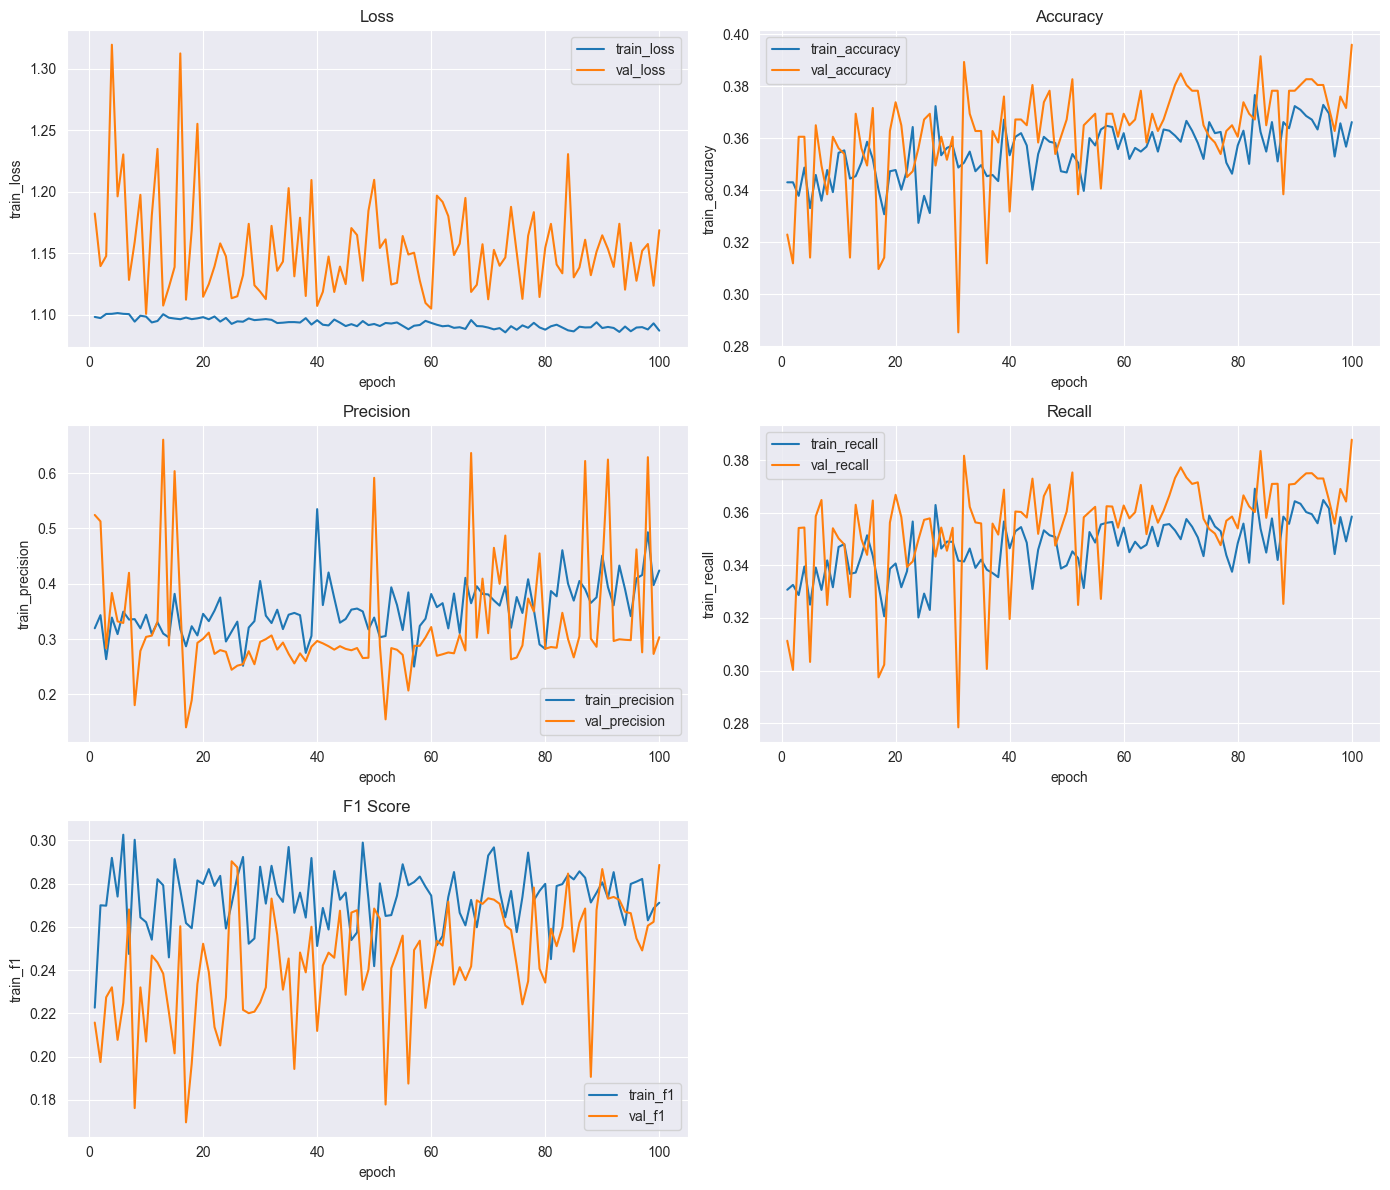

In [12]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment6/tables/training_metrics.csv", index=False)

### Training/Validation Trend (100 epochs)
* Loss stays nearly flat throughout training: train loss remains around ~1.088–1.101 with minimal downward trend, while validation loss oscillates roughly between ~1.10 and ~1.23 without sustained improvement
* Early training shows rapid collapse into biased predictions: confusion matrices heavily concentrate predictions into a single dominant class (often middle or last column dominating)
* Mid training (≈epochs 20–60) shows unstable learning: small fluctuations in accuracy (train ~0.33–0.37, val ~0.31–0.38) without consistent upward trajectory
* Precision and recall are highly volatile: occasional spikes (e.g., precision jumps above 0.6 in some epochs) but not sustained, indicating unstable decision boundaries
* Confusion matrices indicate persistent class imbalance behavior: model repeatedly over-predicts one or two classes while neglecting others (near-zero true positives for at least one class in many epochs)
* Validation performance is consistently close to training performance: indicates weak overfitting but strong underfitting or capacity/optimization limitation
* Late training (≈epochs 60–100) shows mild stabilization but no convergence: metrics oscillate within a narrow band rather than improving
* Accuracy ceiling remains low: train and validation accuracy plateau around ~0.35–0.37, suggesting the model is not learning separable features effectively
* Periodic instability spikes occur in validation precision/recall: likely caused by batch sensitivity or small validation set effects
 Confusion patterns shift slightly across epochs but do not meaningfully improve class separation: the same misclassification structure persists
* Overall learning signal is weak: optimizer reduces neither train nor validation loss meaningfully after early epochs
Final state indicates underfitting or optimization mismatch rather than overfitting: model capacity, feature representation, or learning rate schedule is likely limiting progress

Training shows a mostly flat loss curve, with both train and validation loss oscillating around ~1.09–1.23 and no sustained downward trend. Accuracy also plateaus early at ~0.33–0.37 for both train and validation, indicating no meaningful convergence.

Predictions remain unstable and heavily biased across classes. Confusion matrices frequently show the model over-predicting one or two classes while almost ignoring at least one class entirely, suggesting poor class separation.

Precision and recall fluctuate significantly across epochs, including occasional spikes, but these are not consistent and do not translate into stable performance gains.

Overall, the model is underfitting: it learns a weak, mostly static decision pattern early and fails to improve feature discrimination throughout training.

## Use Tester Module to Test Model

Load Model with State Dict

In [15]:
# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment6"
)

Finished testing epoch 1
Finished testing epoch 3
Finished testing epoch 4
Finished testing epoch 6
Finished testing epoch 7
Finished testing epoch 10
Finished testing epoch 13
Finished testing epoch 16
Finished testing epoch 20
Finished testing epoch 25
Finished testing epoch 30
Finished testing epoch 32
Finished testing epoch 40
Finished testing epoch 50
Finished testing epoch 60
Finished testing epoch 70
Finished testing epoch 80
Finished testing epoch 84
Finished testing epoch 90
Finished testing epoch 100


### Save Test Metrics

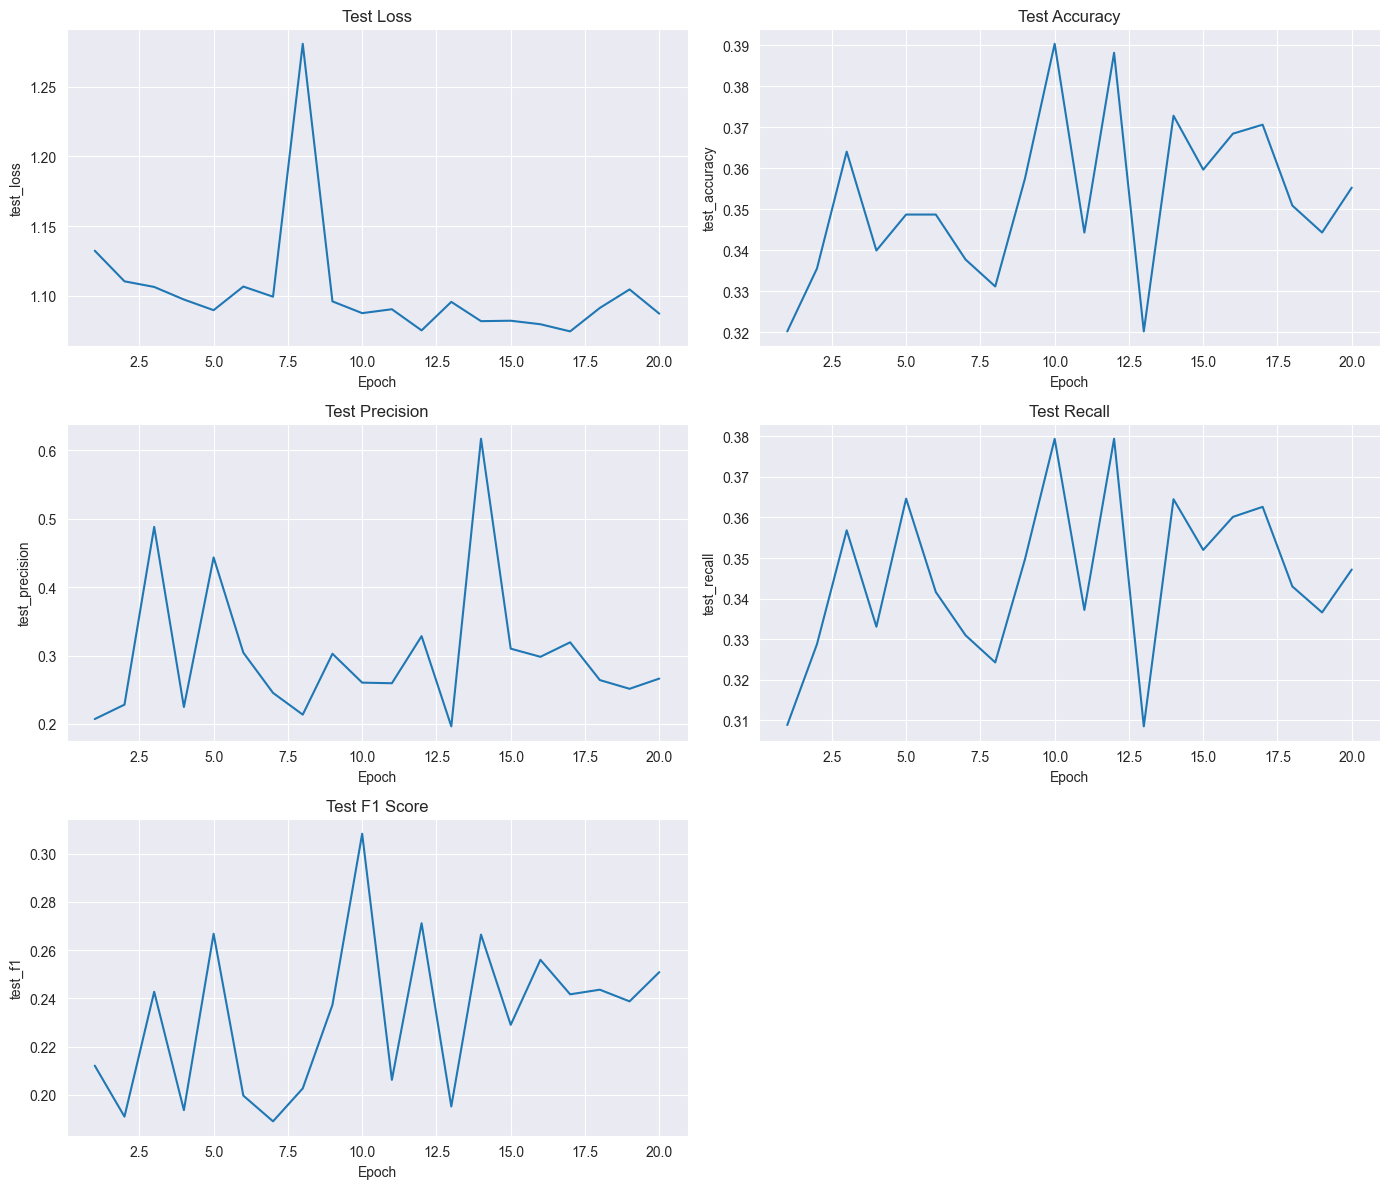

In [16]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment6/tables/test_metrics.csv", index=False)

### Test Performance Trend
* Test loss: Fluctuates around ~1.07–1.13, with one spike at epoch 8 (~1.28). No stable downward trend.
* Test accuracy: Low and unstable, ranging ~0.32 to ~0.39. Best values occur around epochs 10 (~0.390) and 12 (~0.388).
* Precision: Highly inconsistent, varying from ~0.19 to ~0.62. Occasional spikes suggest class imbalance or unstable predictions.
* Recall: Slight upward drift over time (≈0.30 → ≈0.37–0.38), but still weak overall.
* F1 score: Generally low (~0.18–0.31), indicating poor balance between precision and recall.
* Training stability: Metrics oscillate significantly across epochs, suggesting unstable optimization or insufficient convergence.

Overall, the model shows weak and unstable generalization on the test set. Test loss remains roughly flat with occasional spikes, indicating the model is not consistently improving. Accuracy stays low (around 0.32–0.39) with no sustained upward trend, while precision and recall fluctuate heavily, suggesting inconsistent class-level performance. The F1 score remains low across all epochs, confirming that improvements in either precision or recall are not balanced. The behavior suggests the model has not properly converged and may be affected by issues such as limited capacity, noisy gradients, class imbalance, or suboptimal learning rate.